In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In this step, essential libraries such as TensorFlow and Keras are imported to build and train the deep learning model. TensorFlow is used as the backend framework, while Keras provides high-level APIs for model creation. Matplotlib is used for visualization purposes.

In [2]:
!wget https://github.com/chandrikadeb7/Face-Mask-Detection/archive/refs/heads/master.zip
!unzip master.zip

--2026-04-12 09:38:47--  https://github.com/chandrikadeb7/Face-Mask-Detection/archive/refs/heads/master.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/chandrikadeb7/Face-Mask-Detection/zip/refs/heads/master [following]
--2026-04-12 09:38:48--  https://codeload.github.com/chandrikadeb7/Face-Mask-Detection/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 20.205.243.165
Connecting to codeload.github.com (codeload.github.com)|20.205.243.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip.1’

master.zip.1            [                <=> ] 190.46M  17.9MB/s    in 11s     

2026-04-12 09:38:59 (16.8 MB/s) - ‘master.zip.1’ saved [199714088]

Archive:  master.zip
7e500749401bad4bb338790fbdb89b58e41ef2d9
replace Face-Mask-De

The dataset is downloaded from an online source. It contains images of faces categorized into two classes: with mask and without mask. This dataset is used to train the model to classify images based on mask usage.

In [3]:
train_dir = '/content/Face-Mask-Detection-master/dataset'

The path to the dataset directory is defined. This allows the program to access the image data stored in structured folders, which is required for loading and processing the dataset.

In [4]:
img_size = 160
batch_size = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 3274 images belonging to 2 classes.
Found 818 images belonging to 2 classes.


The dataset is divided into training and validation sets using validation_split. The training set is used to train the model, while the validation set is used to evaluate its performance

In [9]:
base_model = MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

A deep learning model is built using MobileNetV2, a pre-trained convolutional neural network. Transfer learning is applied by using pre-trained weights, allowing the model to learn features efficiently.

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

: 

The model is compiled using the Adam optimizer and binary cross-entropy loss function. Accuracy is used as the evaluation metric for binary classification.

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

Epoch 1/8
 61/205 ━━━━━━━━━━━━━━━━━━━━ 58s 408ms/step - accuracy: 0.8366 - loss: 0.3747

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


205/205 ━━━━━━━━━━━━━━━━━━━━ 117s 539ms/step - accuracy: 0.9554 - loss: 0.1192 - val_accuracy: 0.9927 - val_loss: 0.0258
Epoch 2/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 105s 514ms/step - accuracy: 0.9826 - loss: 0.0538 - val_accuracy: 0.9902 - val_loss: 0.0252
Epoch 3/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 102s 497ms/step - accuracy: 0.9832 - loss: 0.0456 - val_accuracy: 0.9853 - val_loss: 0.0500
Epoch 4/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 105s 510ms/step - accuracy: 0.9850 - loss: 0.0437 - val_accuracy: 0.9890 - val_loss: 0.0278
Epoch 5/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 115s 559ms/step - accuracy: 0.9872 - loss: 0.0338 - val_accuracy: 0.9939 - val_loss: 0.0162
Epoch 6/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 103s 501ms/step - accuracy: 0.9896 - loss: 0.0279 - val_accuracy: 0.9976 - val_loss: 0.0161
Epoch 7/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 105s 511ms/step - accuracy: 0.9863 - loss: 0.0351 - val_accuracy: 0.9719 - val_loss: 0.0823
Epoch 8/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 104s 505ms/step - accuracy: 0.9899 - loss: 0.0290 - va

The model is trained using the training dataset and validated on the validation dataset. During training, the model learns patterns that distinguish masked and unmasked faces.

In [16]:
from google.colab import files
uploaded = files.upload()

Saving with face mask 1.jpeg to with face mask 1.jpeg


A new image is uploaded to test the trained model. This simulates real-world input for evaluating model performance.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


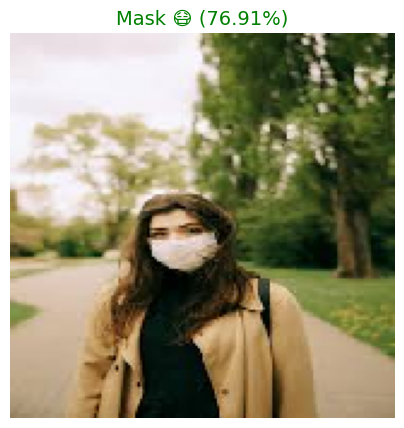

In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# get uploaded image
img_path = list(uploaded.keys())[0]

# load image
img = image.load_img(img_path, target_size=(160,160))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# prediction
prediction = model.predict(img_array)
confidence = prediction[0][0]

# class mapping
if confidence > 0.5:
    result = "No Mask ❌"
    conf = confidence
    color = 'red'
else:
    result = "Mask 😷"
    conf = 1 - confidence
    color = 'green'

# show ONLY image + result
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"{result} ({conf*100:.2f}%)", fontsize=14, color=color)
plt.axis('off')
plt.show()

The trained model predicts whether the uploaded image contains a masked or unmasked face. The output is displayed along with confidence score, demonstrating the model's classification capability.